## Import dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

import warnings

# Ignore all FutureWarnings
warnings.simplefilter(action='ignore', category=FutureWarning)


train = pd.read_csv('../Data/train.csv')
test = pd.read_csv('../Data/test.csv')
print('Size of train dataset: ',train.shape)
train

Size of train dataset:  (140700, 20)


,id,Name,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,0,Aaradhya,Female,49.0,Ludhiana,Working Professional,Chef,NaN,5.0,NaN,NaN,2.0,More than 8 hours,Healthy,BHM,No,1.0,2.0,No,0
1,1,Vivan,Male,26.0,Varanasi,Working Professional,Teacher,NaN,4.0,NaN,NaN,3.0,Less than 5 hours,Unhealthy,LLB,Yes,7.0,3.0,No,1
2,2,Yuvraj,Male,33.0,Visakhapatnam,Student,NaN,5.0,NaN,8.97,2.0,NaN,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
3,3,Yuvraj,Male,22.0,Mumbai,Working Professional,Teacher,NaN,5.0,NaN,NaN,1.0,Less than 5 hours,Moderate,BBA,Yes,10.0,1.0,Yes,1
4,4,Rhea,Female,30.0,Kanpur,Working Professional,Business Analyst,NaN,1.0,NaN,NaN,1.0,5-6 hours,Unhealthy,BBA,Yes,9.0,4.0,Yes,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140695,140695,Vidya,Female,18.0,Ahmedabad,Working Professional,NaN,NaN,5.0,NaN,NaN,4.0,5-6 hours,Unhealthy,Class 12,No,2.0,4.0,Yes,1
140696,140696,Lata,Female,41.0,Hyderabad,Working Professional,Content Writer,NaN,5.0,NaN,NaN,4.0,7-8 hours,Moderate,B.Tech,Yes,6.0,5.0,Yes,0
140697,140697,Aanchal,Female,24.0,Kolkata,Working Professional,Marketing Manager,NaN,3.0,NaN,NaN,1.0,More than 8 hours,Moderate,B.Com,No,4.0,4.0,No,0
140698,140698,Prachi,Female,49.0,Srinagar,Working Professional,Plumber,NaN,5.0,NaN,NaN,2.0,5-6 hours,Moderate,ME,Yes,10.0,1.0,No,0


In [32]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
id,140700.0,70349.500000,40616.735775,0.00,35174.75,70349.50,105524.25,140699.0
Age,140700.0,40.388621,12.384099,18.00,29.00,42.00,51.00,60.0
Academic Pressure,27897.0,3.142273,1.380457,1.00,2.00,3.00,4.00,5.0
Work Pressure,112782.0,2.998998,1.405771,1.00,2.00,3.00,4.00,5.0
CGPA,27898.0,7.658636,1.464466,5.03,6.29,7.77,8.92,10.0
Study Satisfaction,27897.0,2.944940,1.360197,1.00,2.00,3.00,4.00,5.0
Job Satisfaction,112790.0,2.974404,1.416078,1.00,2.00,3.00,4.00,5.0
Work/Study Hours,140700.0,6.252679,3.853615,0.00,3.00,6.00,10.00,12.0
Financial Stress,140696.0,2.988983,1.413633,1.00,2.00,3.00,4.00,5.0
Depression,140700.0,0.181713,0.385609,0.00,0.00,0.00,0.00,1.0


In [33]:
unique_values_df = pd.DataFrame({
    'Column': train.columns,
    'Unique Values': [train[col].nunique() for col in train.columns]
})

unique_values_df

,Column,Unique Values
0,id,140700
1,Name,422
2,Gender,2
3,Age,43
4,City,98
5,Working Professional or Student,2
6,Profession,64
7,Academic Pressure,5
8,Work Pressure,5
9,CGPA,331


In [34]:
train.dtypes

id                                         int64
Name                                      object
Gender                                    object
Age                                      float64
City                                      object
Working Professional or Student           object
Profession                                object
Academic Pressure                        float64
Work Pressure                            float64
CGPA                                     float64
Study Satisfaction                       float64
Job Satisfaction                         float64
Sleep Duration                            object
Dietary Habits                            object
Degree                                    object
Have you ever had suicidal thoughts ?     object
Work/Study Hours                         float64
Financial Stress                         float64
Family History of Mental Illness          object
Depression                                 int64
dtype: object

<Axes: >

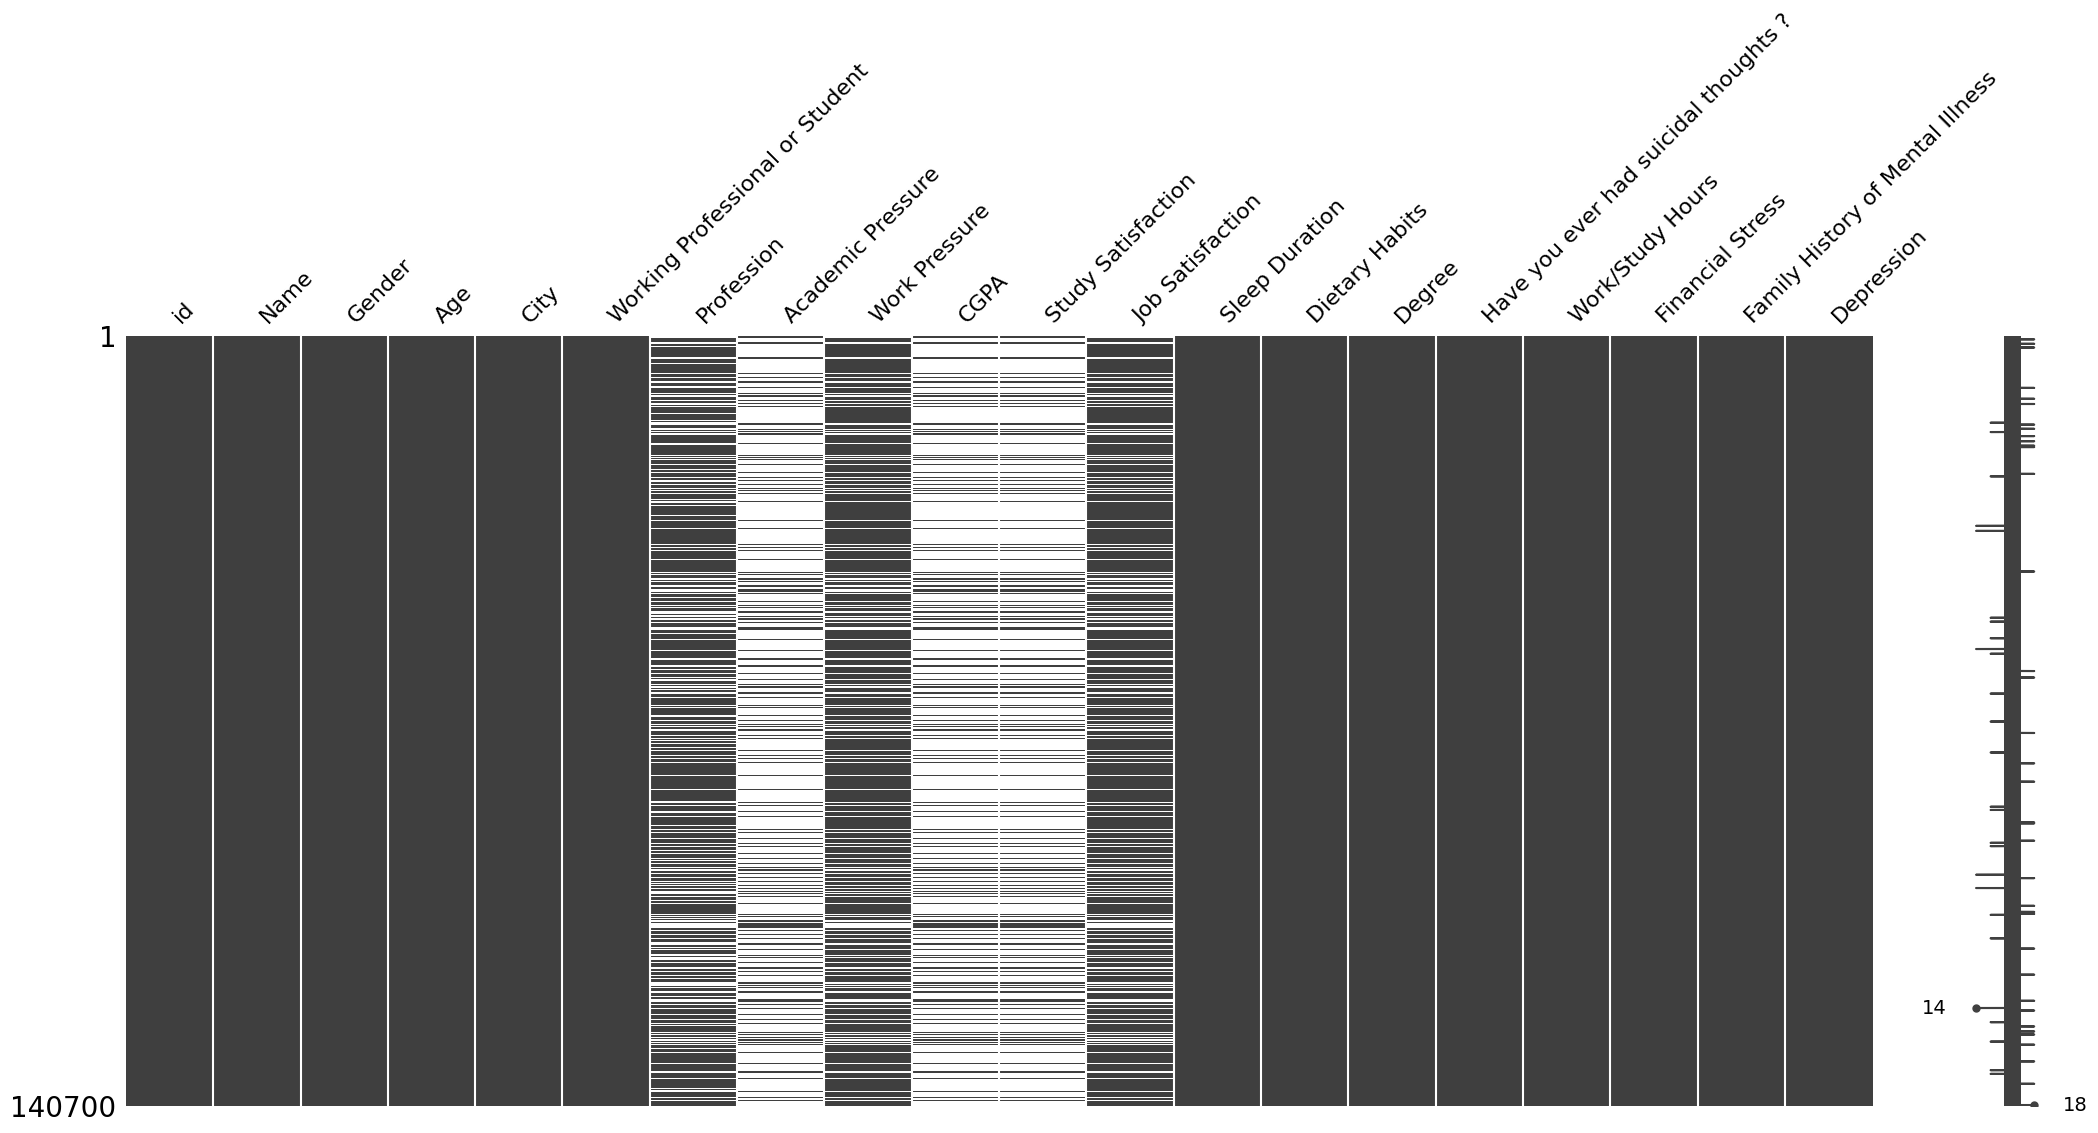

In [35]:
msno.matrix(train)

The dataset have so many missing values.

In [36]:
cols = ['Academic Pressure','Work Pressure','Study Satisfaction','Job Satisfaction']
def missing(df,name):
    missing_data = pd.DataFrame({
        'Columns': df.columns,
        'Number of missing values': df.isnull().sum(),
        'Percentage of missing values': (df.isnull().mean() * 100).round(2)
    }).reset_index(drop=True)
    print('Missing values of {}'.format(name))
    print('_'*50)
    missing_data = missing_data[missing_data['Number of missing values']!= 0]
    return missing_data

missing(train,'Original Train dataset')

Missing values of Original Train dataset
__________________________________________________


,Columns,Number of missing values,Percentage of missing values
6,Profession,36630,26.03
7,Academic Pressure,112803,80.17
8,Work Pressure,27918,19.84
9,CGPA,112802,80.17
10,Study Satisfaction,112803,80.17
11,Job Satisfaction,27910,19.84
13,Dietary Habits,4,0.00
14,Degree,2,0.00
17,Financial Stress,4,0.00


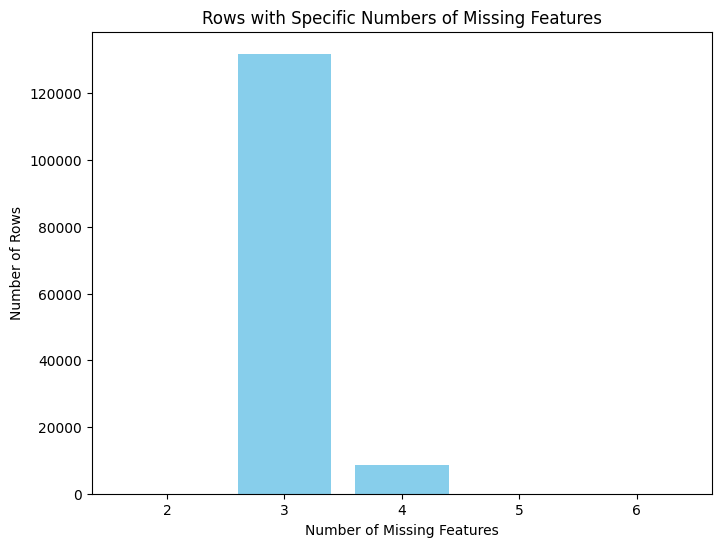

In [37]:
missing_counts = {}

# Count rows with missing values from 1 to 9
for i in range(1, 10):
    rows_with_i_missing = train[train.isnull().sum(axis=1) == i]
    count = len(rows_with_i_missing)
    if count != 0:  # Only add non-zero counts to the dictionary
        missing_counts[i] = count

# Convert dictionary to lists for plotting
missing_values = list(missing_counts.keys())
row_counts = list(missing_counts.values())

# Plot the bar chart
plt.figure(figsize=(8, 6))
plt.bar(missing_values, row_counts, color='skyblue')
plt.xlabel('Number of Missing Features')
plt.ylabel('Number of Rows')
plt.title('Rows with Specific Numbers of Missing Features')
plt.xticks(missing_values)  # Ensure x-axis has all non-zero values
plt.show()

## Drop column Name, Id:

In [38]:
train = train.drop(['Name','id'],axis=1)
train

,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Female,49.0,Ludhiana,Working Professional,Chef,NaN,5.0,NaN,NaN,2.0,More than 8 hours,Healthy,BHM,No,1.0,2.0,No,0
1,Male,26.0,Varanasi,Working Professional,Teacher,NaN,4.0,NaN,NaN,3.0,Less than 5 hours,Unhealthy,LLB,Yes,7.0,3.0,No,1
2,Male,33.0,Visakhapatnam,Student,NaN,5.0,NaN,8.97,2.0,NaN,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
3,Male,22.0,Mumbai,Working Professional,Teacher,NaN,5.0,NaN,NaN,1.0,Less than 5 hours,Moderate,BBA,Yes,10.0,1.0,Yes,1
4,Female,30.0,Kanpur,Working Professional,Business Analyst,NaN,1.0,NaN,NaN,1.0,5-6 hours,Unhealthy,BBA,Yes,9.0,4.0,Yes,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140695,Female,18.0,Ahmedabad,Working Professional,NaN,NaN,5.0,NaN,NaN,4.0,5-6 hours,Unhealthy,Class 12,No,2.0,4.0,Yes,1
140696,Female,41.0,Hyderabad,Working Professional,Content Writer,NaN,5.0,NaN,NaN,4.0,7-8 hours,Moderate,B.Tech,Yes,6.0,5.0,Yes,0
140697,Female,24.0,Kolkata,Working Professional,Marketing Manager,NaN,3.0,NaN,NaN,1.0,More than 8 hours,Moderate,B.Com,No,4.0,4.0,No,0
140698,Female,49.0,Srinagar,Working Professional,Plumber,NaN,5.0,NaN,NaN,2.0,5-6 hours,Moderate,ME,Yes,10.0,1.0,No,0


## Clean data column Sleep Duration:

In [39]:
print('Number of Sleep Duration BEFORE cleaning: ',train['Sleep Duration'].nunique())
train['Sleep Duration'].value_counts()

Number of Sleep Duration BEFORE cleaning:  36


Sleep Duration
Less than 5 hours    38784
7-8 hours            36969
More than 8 hours    32726
5-6 hours            32142
3-4 hours               12
6-7 hours                8
4-5 hours                7
2-3 hours                5
4-6 hours                5
6-8 hours                4
1-6 hours                4
No                       4
9-11 hours               2
10-11 hours              2
Sleep_Duration           2
Unhealthy                2
45                       2
8-9 hours                2
10-6 hours               1
9-5                      1
45-48 hours              1
3-6 hours                1
Work_Study_Hours         1
49 hours                 1
than 5 hours             1
Pune                     1
9-6 hours                1
8 hours                  1
35-36 hours              1
Indore                   1
1-3 hours                1
55-66 hours              1
Moderate                 1
40-45 hours              1
1-2 hours                1
9-5 hours                1
Name: count, 

In [40]:
### 40-45 hours, 50-75 hours, 20-21 hours, 60-65 hours, 49 hours, 45-48 hours, 35-36 hours, 55-66 hours.
### Those are incorrect data, this might be data weekly hours, not daily hours

def categorize_weekly_sleep(duration):
    numbers = [int(n) for n in duration.split()[0].split('-')]
    avg_weekly_hours = sum(numbers) / len(numbers)  # Calculate average if range
    avg_daily_hours = avg_weekly_hours / 7
    if avg_daily_hours < 5:
        return 'Less than 5 hours'
    elif 5 <= avg_daily_hours <= 6:
        return '5-6 hours'
    elif 7 <= avg_daily_hours <= 8:
        return '7-8 hours'
    else:
        return 'More than 8 hours'
weekly_hours = ['40-45 hours', '50-75 hours', '20-21 hours', '60-65 hours','49 hours', '45-48 hours', '35-36 hours', '55-66 hours']

def correct_sleep(df):
    ### Category Less than 5 hours
    df['Sleep Duration'] = df['Sleep Duration'].str.replace('1-2 hours|3-4 hours|4-5 hours|2-3 hours|1-3 hours','Less than 5 hours',regex=True)
    df['Sleep Duration'] = df['Sleep Duration'].replace('than 5 hours','Less than 5 hours')
    ### Category Less than 5-6 hours
    df['Sleep Duration'] = df['Sleep Duration'].str.replace('6-7 hours|4-6 hours|1-6 hours','5-6 hours',regex=True)
    df['Sleep Duration'] = df['Sleep Duration'].replace('6 hours','5-6 hours')
    ### Category Less than 7-8 hours
    df['Sleep Duration'] = df['Sleep Duration'].replace('8 hours', '7-8 hours')
    df['Sleep Duration'] = df['Sleep Duration'].str.replace('6-8 hours','7-8 hours',regex=True)
    ### Category More than 8 hours
    df['Sleep Duration'] = df['Sleep Duration'].str.replace('8-89 hours|9-11 hours|8-9 hours|10-11 hours|9-10 hours','More than 8 hours',regex=True)
    ## Cateogory Weekly Hours into Daily Hours    
    train.loc[train['Sleep Duration'].isin(weekly_hours), 'Sleep Duration'] = train.loc[train['Sleep Duration'].isin(weekly_hours), 'Sleep Duration'].apply(categorize_weekly_sleep)

    return df
correct_sleep(train)
train['Sleep Duration'].value_counts()

Sleep Duration
Less than 5 hours    38811
7-8 hours            36975
More than 8 hours    32735
5-6 hours            32160
No                       4
Unhealthy                2
45                       2
Sleep_Duration           2
Indore                   1
9-6 hours                1
Moderate                 1
10-6 hours               1
Work_Study_Hours         1
3-6 hours                1
9-5                      1
Pune                     1
9-5 hours                1
Name: count, dtype: int64

For the rest value, we will random it into 4 categories

In [41]:
import random
def random_categorize_sleep(df, seed=42):
    # Set the seed for reproducibility
    random.seed(seed)
    np.random.seed(seed)

    # Get value counts for 'Sleep Duration'
    value_counts = df['Sleep Duration'].value_counts()
    
    # Define the categories
    categories = ['Less than 5 hours', '5-6 hours', '7-8 hours', 'More than 8 hours']
    
    # Loop through value counts and check for counts less than 10
    for value, count in value_counts.items():
        if count < 10:
            # Randomly assign a category to rows with less than 10 occurrences
            df.loc[df['Sleep Duration'] == value, 'Sleep Duration'] = random.choice(categories)
    
    return df
train = random_categorize_sleep(train)

## Change to category
train['Sleep Duration'] = train['Sleep Duration'].str.replace('Less than','<')
train['Sleep Duration'] = train['Sleep Duration'].str.replace('More than','>')
sleep_categories = ['< 5 hours', '5-6 hours', '7-8 hours', '> 8 hours']
train['Sleep Duration'] = pd.Categorical(train['Sleep Duration'], categories=sleep_categories, ordered=True)
print('Number of Sleep Duration AFTER cleaning: ',train['Sleep Duration'].nunique())
train['Sleep Duration'].value_counts()

Number of Sleep Duration AFTER cleaning:  4


Sleep Duration
< 5 hours    38822
7-8 hours    36977
> 8 hours    32736
5-6 hours    32165
Name: count, dtype: int64

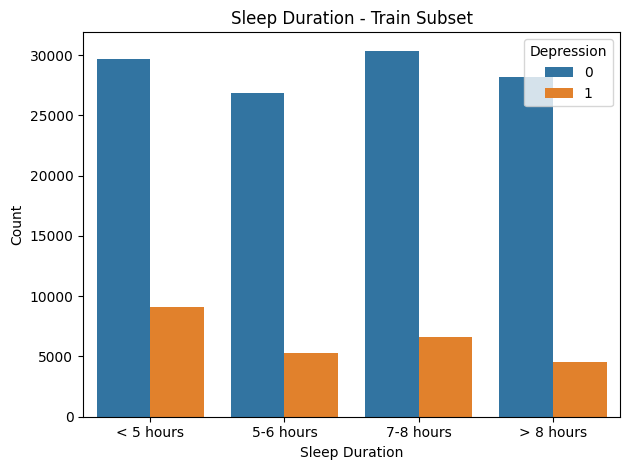

In [42]:
sns.countplot(x='Sleep Duration', data=train, hue='Depression')
plt.title('Sleep Duration - Train Subset')
plt.xlabel('Sleep Duration')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## Clean data column Dietary Habits:

In [43]:
print('Number of Dietary Habits BEFORE cleaning: ',train['Dietary Habits'].nunique())
train['Dietary Habits'].value_counts()

Number of Dietary Habits BEFORE cleaning:  23


Dietary Habits
Moderate             49705
Unhealthy            46227
Healthy              44741
Yes                      2
No                       2
More Healthy             2
No Healthy               1
Class 12                 1
Indoor                   1
Male                     1
Vegas                    1
M.Tech                   1
Less Healthy             1
1.0                      1
Electrician              1
Hormonal                 1
Mihir                    1
Less than Healthy        1
3                        1
Gender                   1
BSc                      1
Pratham                  1
2                        1
Name: count, dtype: int64

In [44]:
def correct_habit(df):
    ### Category Unhealthy
    df['Dietary Habits'] = df['Dietary Habits'].str.replace('No|Less Healthy|Less than Healthy|5 Unhealthy|3|1.0|Unhealthy Healthy','Unhealthy',regex=True)
    df['Dietary Habits'] = df['Dietary Habits'].replace('2','Unhealthy')
    ### Category Healthy
    df['Dietary Habits'] = df['Dietary Habits'].str.replace('Yes|More Healthy|5 Healthy','Healthy',regex=True)
    return df
correct_habit(train)

### Other value we change to Moderate
train.loc[~train['Dietary Habits'].isin(["Healthy", "Unhealthy"]), 'Dietary Habits'] = "Moderate"
train['Dietary Habits'].value_counts()
habit_categories = ['Unhealthy','Moderate','Healthy']
train['Dietary Habits'] = pd.Categorical(train['Dietary Habits'], categories=habit_categories, ordered=True)
print('Number of Dietary Habits AFTER cleaning: ',train['Dietary Habits'].nunique())
train['Dietary Habits'].value_counts()

Number of Dietary Habits AFTER cleaning:  3


Dietary Habits
Moderate     49721
Unhealthy    46234
Healthy      44745
Name: count, dtype: int64

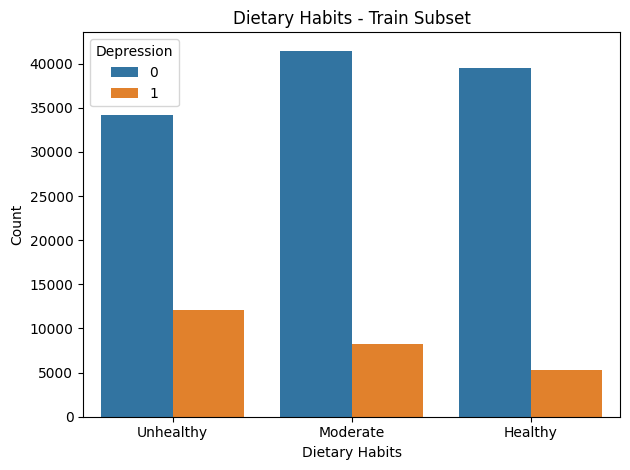

In [45]:
sns.countplot(x='Dietary Habits', data=train, hue='Depression')
plt.title('Dietary Habits - Train Subset')
plt.xlabel('Dietary Habits')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## Clean data column Profession:

In [46]:
print('Number of Profession BEFORE cleaning: ',train['Profession'].nunique())
def correct_profession(df):
    df['Profession'] = df['Profession'].str.replace('Finanancial Analyst|Academic|Profession','Financial Analyst',regex=True)
    df['Profession'] = df['Profession'].str.replace('City Manager','Manager',regex=True)
    df['Profession'] = df['Profession'].str.replace('Family Consultant|City Consultant','Consultant',regex=True)
    df['Profession'] = df['Profession'].str.replace('MBA|BCA','Business Analyst',regex=True)
    df['Profession'] = df['Profession'].str.replace('Dev','Software Engineer',regex=True)
    df['Profession'] = df['Profession'].str.replace('M.Pharm','Pharmacist',regex=True)
    df['Profession'] = df['Profession'].str.replace('Medical Doctor|B.Pharm|MD|Surgeon','Doctor',regex=True)
    df['Profession'] = df['Profession'].str.replace('M.Ed|B.Ed|PhD','Teacher',regex=True)
    df['Profession'] = df['Profession'].str.replace('ME|BE','Mechanical Engineer',regex=True)
    return df
correct_profession(train)
train['Profession'] = train['Profession'].str.replace('Working Financial Analystal','Financial Analyst')
train['Profession'] = train['Profession'].replace('Analyst','Financial Analyst')
count_profession = train['Profession'].value_counts()
profession_below_20 = []
for i,c in count_profession.items():
    if c < 20:
        profession_below_20.append(i)
print('Profession appear below 20:')
profession_below_20

Number of Profession BEFORE cleaning:  64
Profession appear below 20:


['Student',
 'Yogesh',
 'Unemployed',
 'LLM',
 'B.Com',
 'FamilyVirar',
 'BBA',
 'MBBS',
 'Patna',
 'Unveil',
 'Nagpur',
 'Moderate',
 'Pranav',
 'Visakhapatnam',
 'Yuvraj']

In [47]:
train.loc[train['Degree'] == 'Class 12', 'Profession'] = 'Unemployed'
train.loc[train['Profession'] == 'Unemployed', 'Degree'] = 'Class 12'
train.loc[train['Working Professional or Student'] == 'Student','Profession'] = 'Student'
train.loc[train['Profession'] == 'Student','Working Professional or Student'] = 'Student'
train['Profession'].value_counts()

Profession
Student                   27905
Teacher                   24879
Unemployed                 8652
Content Writer             7811
Architect                  4361
Consultant                 4228
HR Manager                 4019
Pharmacist                 3890
Doctor                     3252
Business Analyst           3166
Entrepreneur               2967
Chemist                    2966
Financial Analyst          2910
Chef                       2857
Educational Consultant     2851
Data Scientist             2390
Researcher                 2328
Lawyer                     2210
Customer Support           2054
Marketing Manager          1976
Pilot                      1911
Travel Consultant          1859
Plumber                    1746
Sales Executive            1739
Manager                    1736
Judge                      1709
Electrician                1582
Software Engineer          1510
Civil Engineer             1468
UX/UI Designer             1451
Digital Marketer           13

Replace profession with the most

Number of Profession BEFORE cleaning:  36


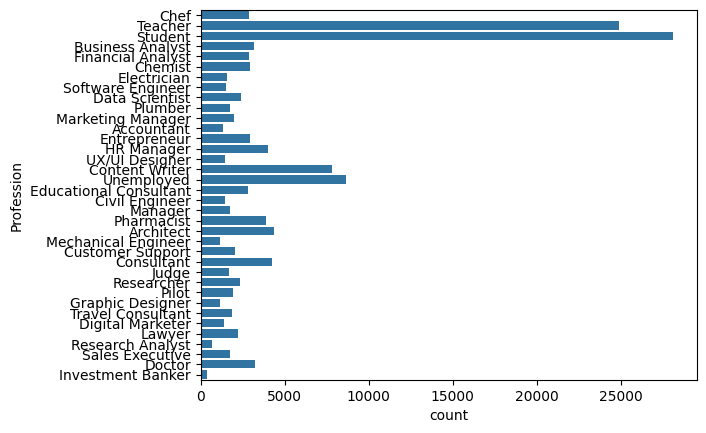

In [48]:
# Find the most frequent Profession (ignoring NaNs)
most_prof = train['Profession'].mode()[0]

# Get value counts once
counts = train['Profession'].value_counts()

# Replace rare categories or NaN with the most frequent
train['Profession'] = train['Profession'].apply(
    lambda x: most_prof if pd.isna(x) or counts.get(x, 0) < 20 else x)
print('Number of Profession BEFORE cleaning: ',train['Profession'].nunique())
sns.countplot(y='Profession',data=train)
plt.show()

## Clean data column Degree:

In [49]:
degree = {
    "BCom": "B.Com", "B.Com": "B.Com", "B.Comm": "B.Com",
    "B.Tech": "B.Tech", "BTech": "B.Tech", "B.T": "B.Tech",
    "BSc": "B.Sc", "B.Sc": "B.Sc", "Bachelor of Science": "B.Sc",
    "BArch": "B.Arch", "B.Arch": "B.Arch",
    "BA": "B.A", "B.A": "B.A",
    "BBA": "BBA", "BB": "BBA",
    "BCA": "BCA",
    "BE": "BE",
    "BEd": "B.Ed", "B.Ed": "B.Ed",
    "BPharm": "B.Pharm", "B.Pharm": "B.Pharm",
    "BHM": "BHM",
    "LLB": "LLB", "LL B": "LLB", "LL BA": "LLB", "LL.Com": "LLB", "LLCom": "LLB",
    "MCom": "M.Com", "M.Com": "M.Com",
    "M.Tech": "M.Tech", "MTech": "M.Tech", "M.T": "M.Tech",
    "MSc": "M.Sc", "M.Sc": "M.Sc", "Master of Science": "M.Sc",
    "MBA": "MBA",
    "MCA": "MCA",
    "MD": "MD",
    "ME": "ME",
    "MEd": "M.Ed", "M.Ed": "M.Ed",
    "MArch": "B.Arch", "M.Arch": "B.Arch",
    "MPharm": "M.Pharm", "M.Pharm": "M.Pharm",
    "MA": "MA", "M.A": "MA",
    "MPA": "MA",
    "LLM": "LLM",
    "PhD": "PhD",
    "MBBS": "MBBS",
    "CA": "CA",
    "Class 12": "Class 12", "12th": "Class 12",
    "Class 11": "Class 12", "11th": "Class 12"
}
print('Number of Degree before cleaning: ',train['Degree'].nunique())
train['Degree'] = train['Degree'].map(degree)
print('Number of Degree after cleaning: ',train['Degree'].nunique())

train.loc[
    (train['Working Professional or Student'] == 'Student') & (train['Degree'].isna()),
    'Degree'] = 'Class 12'

Number of Degree before cleaning:  115
Number of Degree after cleaning:  26


Reassign some degree

In [50]:
most_common_degree = train.groupby('Profession')['Degree'].agg(lambda x: x.mode()[0]).to_dict()

# Step 2: Count Degree occurrences per Profession
degree_counts = train.groupby(['Profession', 'Degree']).size().reset_index(name='count')

# Step 3: Replace rare Degrees (<10) with most common Degree for that Profession
for _, row in degree_counts.iterrows():
    if row['count'] < 10:
        prof = row['Profession']
        deg = row['Degree']
        train.loc[(train['Profession'] == prof) & (train['Degree'] == deg), 'Degree'] = most_common_degree[prof]

# Step 4: Fill missing Degree values with most common Degree per Profession
train['Degree'] = train.apply(
    lambda row: most_common_degree[row['Profession']] if pd.isna(row['Degree']) else row['Degree'],
    axis=1)

## Clean data column City:

In [51]:
valid_cities = [
    'Ludhiana', 'Varanasi', 'Visakhapatnam', 'Mumbai', 'Kanpur', 'Ahmedabad',
    'Thane', 'Nashik', 'Bangalore', 'Patna', 'Rajkot', 'Jaipur', 'Pune',
    'Lucknow', 'Meerut', 'Agra', 'Surat', 'Faridabad', 'Hyderabad',
    'Srinagar', 'Ghaziabad', 'Kolkata', 'Chennai', 'Kalyan', 'Nagpur',
    'Vadodara', 'Vasai-Virar', 'Delhi', 'Bhopal', 'Indore']

print('Number of City before Cleaning: ',train['City'].nunique())
train['City'] = train['City'].apply(lambda x: x if x in valid_cities else 'Unknown')
mode_city = train.loc[train['City'] != 'Unknown', 'City'].mode()[0]

# Step 2: Replace 'Unknown' with mode
train['City'] = train['City'].replace('Unknown', mode_city)
print('Number of City after Cleaning: ',train['City'].nunique())

Number of City before Cleaning:  98
Number of City after Cleaning:  30


In [52]:
# region_mapping = {
#     'North': ['Ludhiana', 'Varanasi', 'Kanpur', 'Patna', 'Jaipur', 'Lucknow', 'Meerut', 'Agra', 'Faridabad', 'Ghaziabad', 'Delhi', 'Srinagar'],
#     'South': ['Bangalore', 'Chennai', 'Hyderabad'],
#     'West': ['Mumbai', 'Thane', 'Nashik', 'Pune', 'Ahmedabad', 'Rajkot', 'Surat', 'Vadodara', 'Vasai-Virar', 'Kalyan','Nagpur'],
#     'Central': ['Bhopal', 'Indore'],
#     'East': ['Kolkata', 'Visakhapatnam']
# }

# # Create a reverse mapping to map city to region
# city_to_region = {city: region for region, cities in region_mapping.items() for city in cities}

# # Step 2: Map city to region, unknown cities get 'Other'
# train['Region'] = train['City'].map(city_to_region)
# sns.countplot(y='Region',data=train)

## Fill missing values

In [53]:
missing(train,'Train before cleaning')

Missing values of Train before cleaning
__________________________________________________


,Columns,Number of missing values,Percentage of missing values
5,Academic Pressure,112803,80.17
6,Work Pressure,27918,19.84
7,CGPA,112802,80.17
8,Study Satisfaction,112803,80.17
9,Job Satisfaction,27910,19.84
15,Financial Stress,4,0.00


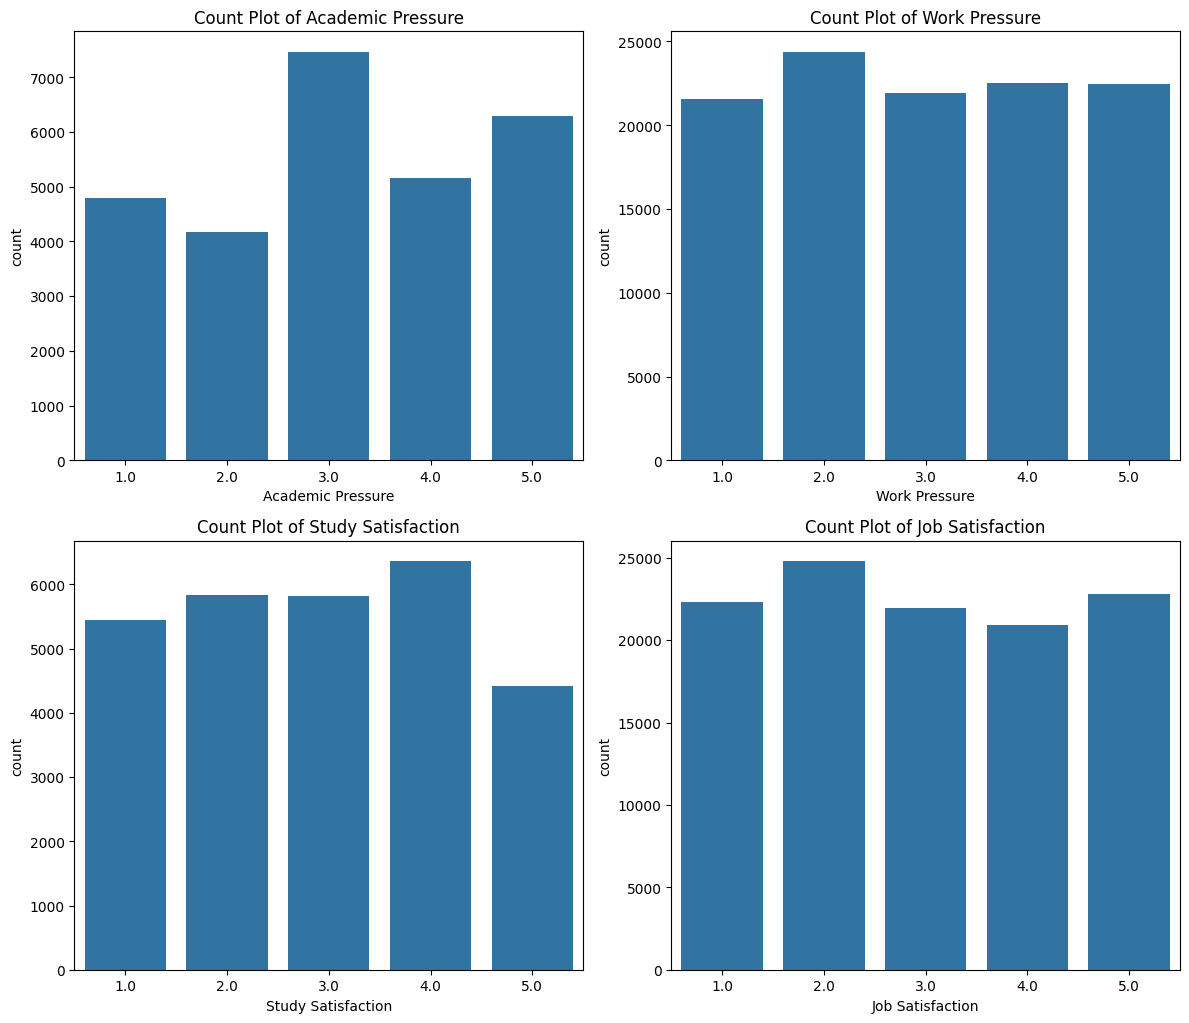

In [54]:
cols = ['Academic Pressure','Work Pressure','Study Satisfaction','Job Satisfaction']
# Set up the figure size (wider for horizontal plots)
plt.figure(figsize=(12, 15))

# Loop over columns and create subplots
for i, col in enumerate(cols, 1):
    plt.subplot(3, 2, i)  # 3 rows, 2 columns layout
    sns.countplot(x=col, data=train)
    plt.title(f'Count Plot of {col}')

plt.tight_layout()
plt.show()

<Figure size 800x400 with 0 Axes>

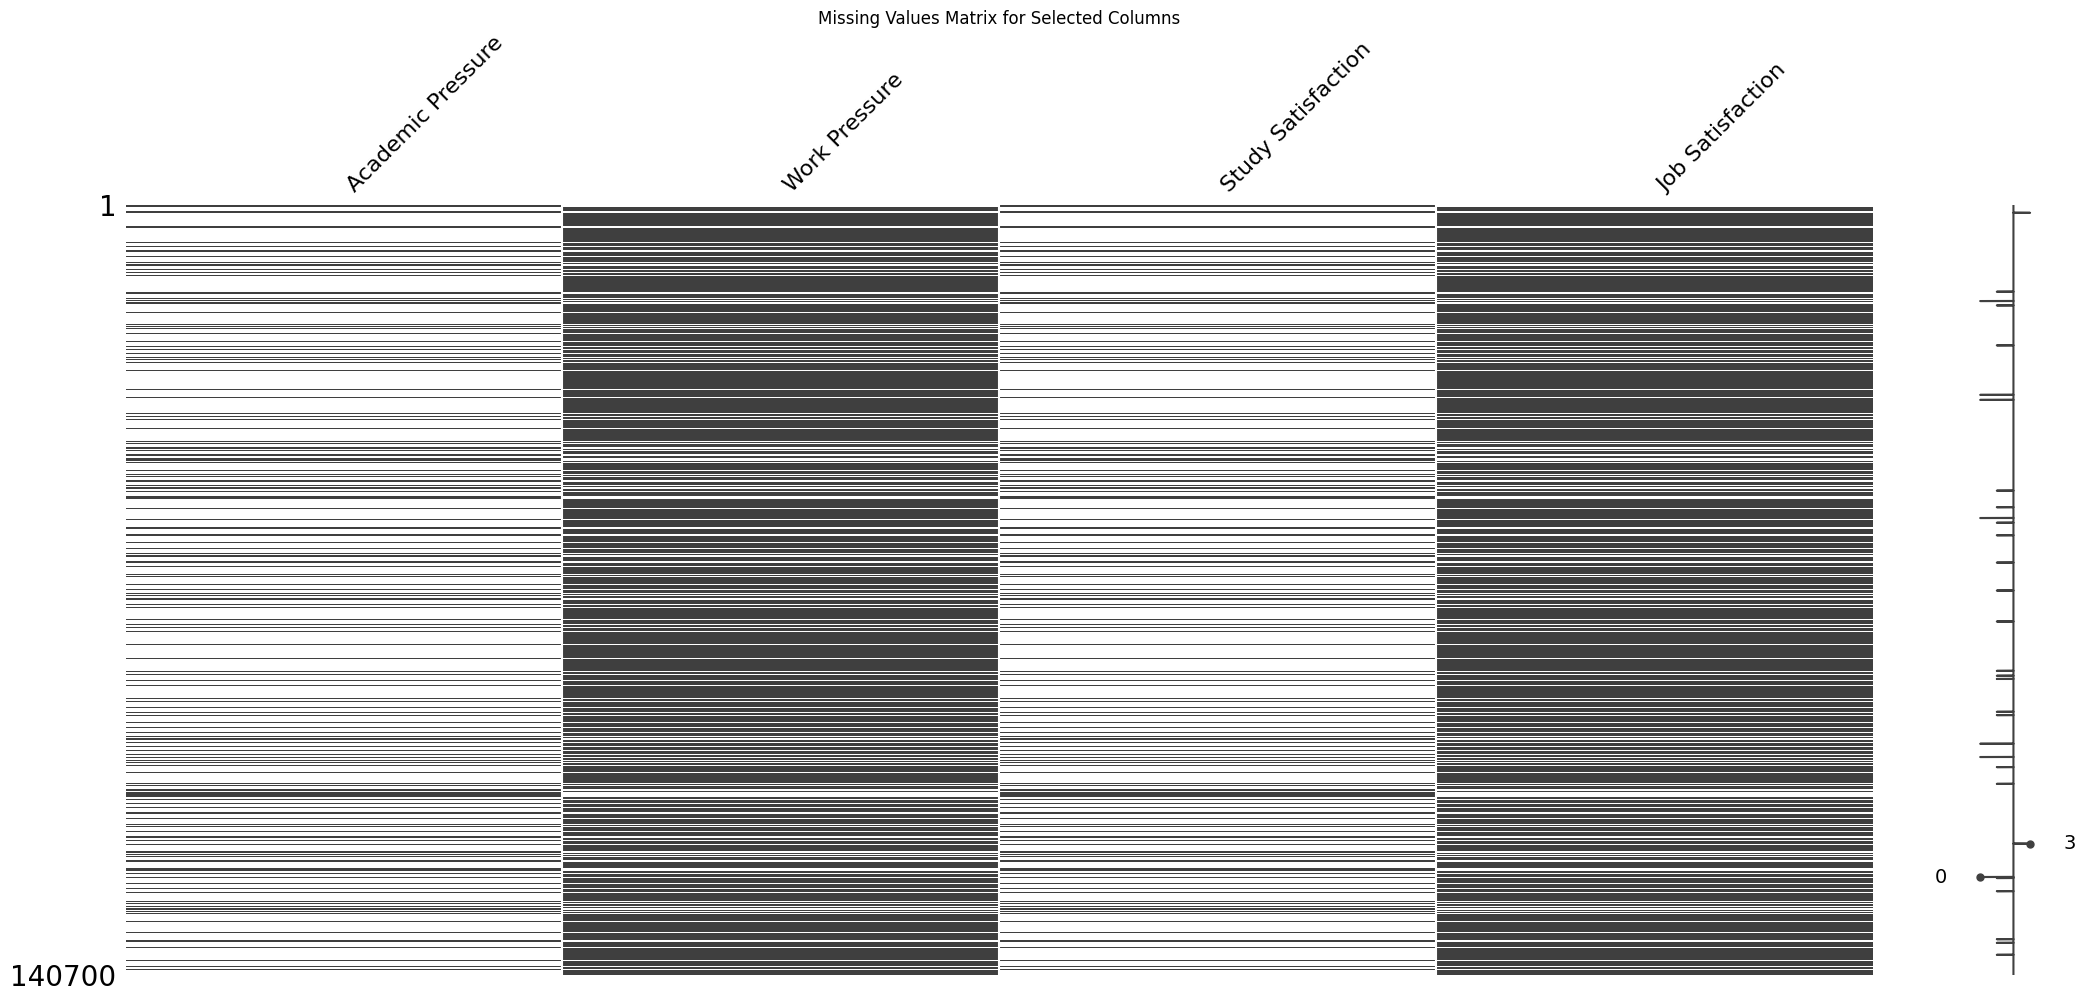

In [55]:
# Plot missing values matrix
plt.figure(figsize=(8,4))
msno.matrix(train[cols])
plt.title("Missing Values Matrix for Selected Columns")
plt.show()

In [56]:
# Create mask for students
student_mask = (train['Working Professional or Student'] == 'Student') | (train['Profession'] == 'Student')

# Fill missing values for students
train.loc[student_mask, 'Work Pressure'] = train.loc[student_mask, 'Work Pressure'].fillna(0)
train.loc[student_mask, 'Job Satisfaction'] = train.loc[student_mask, 'Job Satisfaction'].fillna(0)

# Create mask for working professionals or non-students
not_student_mask = (train['Working Professional or Student'] == 'Working Professional') | (train['Profession'] != 'Student')

# Fill missing values for the selected rows
train.loc[not_student_mask, 'Academic Pressure'] = train.loc[not_student_mask, 'Academic Pressure'].fillna(0)
train.loc[not_student_mask, 'Study Satisfaction'] = train.loc[not_student_mask, 'Study Satisfaction'].fillna(0)
train.loc[not_student_mask, 'CGPA'] = train.loc[not_student_mask,'CGPA'].fillna(0)

In [57]:
missing(train,'Train after cleaning')

Missing values of Train after cleaning
__________________________________________________


,Columns,Number of missing values,Percentage of missing values
5,Academic Pressure,13,0.01
6,Work Pressure,15,0.01
7,CGPA,13,0.01
8,Study Satisfaction,14,0.01
9,Job Satisfaction,12,0.01
15,Financial Stress,4,0.00


In [58]:
scale_cols = ['Academic Pressure', 'Work Pressure', 'Study Satisfaction', 'Job Satisfaction', 'Financial Stress']

# Fill missing values with mode for 1-5 scale columns
for col in scale_cols:
    mode_val = train[col][train[col].between(1, 5)].mode()[0]
    train[col] = train[col].fillna(mode_val)

# Fill missing values for CGPA with median
median_cgpa = train['CGPA'].median()
train['CGPA'] = train['CGPA'].fillna(median_cgpa)
cols = [col for col in train.columns if col != 'Depression']

# Add 'Depression' at the end
cols.append('Depression')

# Reorder DataFrame
train = train[cols]
train

,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Female,49.0,Ludhiana,Working Professional,Chef,0.0,5.0,0.00,0.0,2.0,> 8 hours,Healthy,BHM,No,1.0,2.0,No,0
1,Male,26.0,Varanasi,Working Professional,Teacher,0.0,4.0,0.00,0.0,3.0,< 5 hours,Unhealthy,LLB,Yes,7.0,3.0,No,1
2,Male,33.0,Visakhapatnam,Student,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
3,Male,22.0,Mumbai,Working Professional,Teacher,0.0,5.0,0.00,0.0,1.0,< 5 hours,Moderate,BBA,Yes,10.0,1.0,Yes,1
4,Female,30.0,Kanpur,Working Professional,Business Analyst,0.0,1.0,0.00,0.0,1.0,5-6 hours,Unhealthy,BBA,Yes,9.0,4.0,Yes,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140695,Female,18.0,Ahmedabad,Working Professional,Unemployed,0.0,5.0,0.00,0.0,4.0,5-6 hours,Unhealthy,Class 12,No,2.0,4.0,Yes,1
140696,Female,41.0,Hyderabad,Working Professional,Content Writer,0.0,5.0,0.00,0.0,4.0,7-8 hours,Moderate,B.Tech,Yes,6.0,5.0,Yes,0
140697,Female,24.0,Kolkata,Working Professional,Marketing Manager,0.0,3.0,0.00,0.0,1.0,> 8 hours,Moderate,B.Com,No,4.0,4.0,No,0
140698,Female,49.0,Srinagar,Working Professional,Plumber,0.0,5.0,0.00,0.0,2.0,5-6 hours,Moderate,ME,Yes,10.0,1.0,No,0


In [59]:
int_cols = ['Academic Pressure', 'Work Pressure', 'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours','Financial Stress']
train[int_cols] = train[int_cols].astype(int)

In [ ]:
train.to_csv('../EDA/train_clean.csv',index=False)